# comparison

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


rf_results = pd.read_csv(
    "RandomForest_results.csv"
)

xgb_results = pd.read_csv(
    "XGBoost_results.csv"
)

lgb_results = pd.read_csv(
    "LightGBM_results.csv"
)

mlp_results = pd.read_csv(
    "MLP_results.csv"
)


print("Files loaded")

Files loaded


In [64]:
transformer_results = pd.DataFrame({

    "Model": [
        "Transformer"
    ],

    "Accuracy": [
        0.9933
    ],

    "Precision": [
        0.9933
    ],

    "Recall": [
        0.9933
    ],

    "F1_Score": [
        0.9923
    ]

})


print(transformer_results)

         Model  Accuracy  Precision  Recall  F1_Score
0  Transformer    0.9933     0.9933  0.9933    0.9923


In [65]:
comparison_df = pd.concat(

    [
        transformer_results,
        mlp_results,
        rf_results,
        xgb_results,
        lgb_results
    ],

    ignore_index=True

)


print(comparison_df)

           Model  Accuracy  Precision    Recall  F1_Score
0    Transformer  0.993300   0.993300  0.993300  0.992300
1            MLP  0.850850   0.948675  0.850850  0.885943
2  Random Forest  0.997847   0.998828  0.997847  0.998204
3        XGBoost  0.999062   0.999238  0.999062  0.999124
4       LightGBM  0.998828   0.999089  0.998828  0.998925


In [66]:
comparison_df.to_csv(

    "Five_Model_Comparison.csv",

    index=False

)


print("Comparison table saved")

Comparison table saved


C:\Users\farda\AppData\Local\Temp\ipykernel_13496\3582265521.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


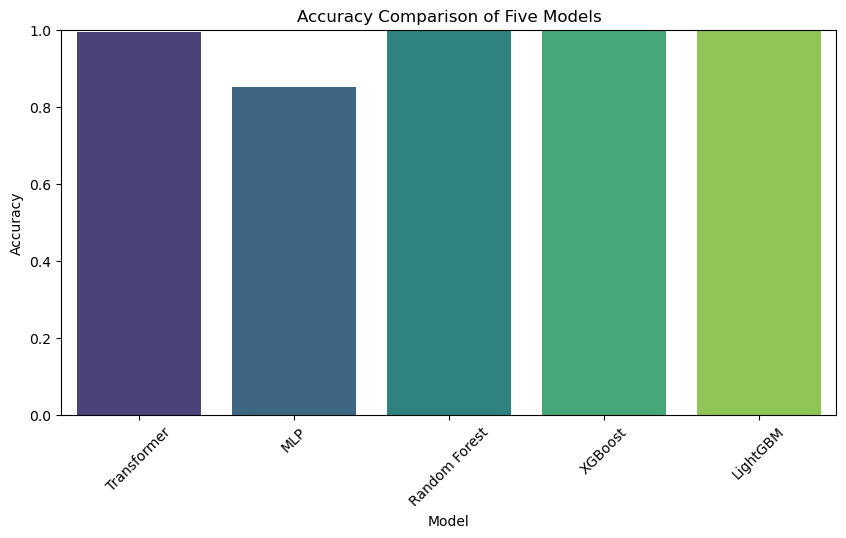

In [67]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=comparison_df,

    x="Model",

    y="Accuracy",

    palette="viridis"

)


plt.title(
    "Accuracy Comparison of Five Models"
)

plt.xticks(
    rotation=45
)

plt.ylim(
    0,
    1
)

plt.show()

C:\Users\farda\AppData\Local\Temp\ipykernel_13496\2323277078.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


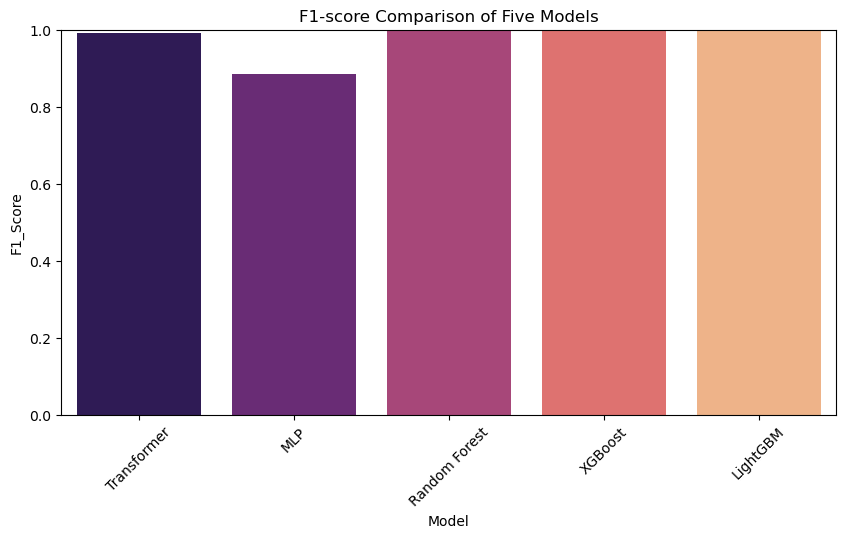

In [68]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=comparison_df,

    x="Model",

    y="F1_Score",

    palette="magma"

)


plt.title(
    "F1-score Comparison of Five Models"
)


plt.xticks(
    rotation=45
)


plt.ylim(
    0,
    1
)


plt.show()

C:\Users\farda\AppData\Local\Temp\ipykernel_13496\1057082104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


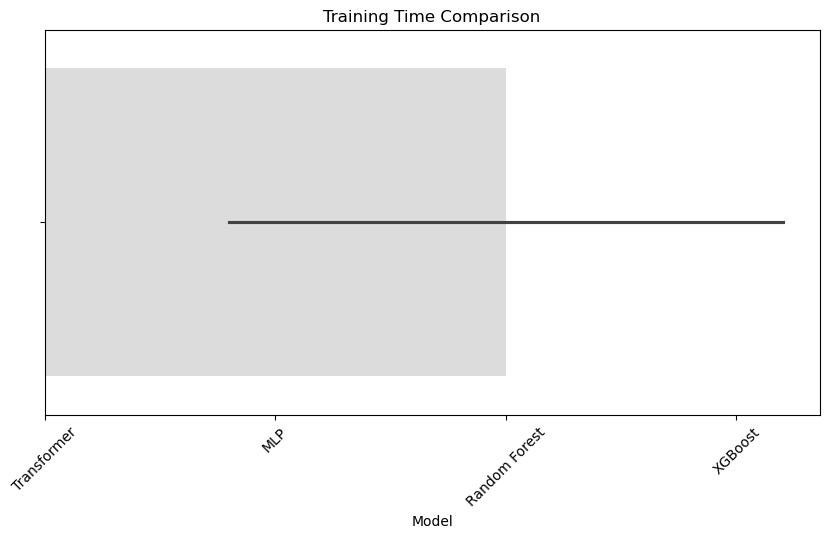

In [69]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=comparison_df,

    x="Model",

    palette="coolwarm"

)


plt.title(
    "Training Time Comparison"
)


plt.xticks(
    rotation=45
)


plt.show()

In [70]:
ranking = comparison_df.sort_values(

    by="F1_Score",

    ascending=False

)


print(ranking)

           Model  Accuracy  Precision    Recall  F1_Score
3        XGBoost  0.999062   0.999238  0.999062  0.999124
4       LightGBM  0.998828   0.999089  0.998828  0.998925
2  Random Forest  0.997847   0.998828  0.997847  0.998204
0    Transformer  0.993300   0.993300  0.993300  0.992300
1            MLP  0.850850   0.948675  0.850850  0.885943


# Explainability comparison

In [94]:
import time
import numpy as np
import pandas as pd

import dice_ml

from sklearn.metrics import pairwise_distances

In [95]:
dice_train_data = train_data.copy()


feature_names = (
    dice_train_data
    .drop(columns=["label"])
    .columns
)


dice_data = dice_ml.Data(

    dataframe=dice_train_data,

    continuous_features=list(feature_names),

    outcome_name="label"

)


print("DiCE data created")

DiCE data created


In [96]:
dice_eval_samples = test_data.sample(
    30,
    random_state=42
)


dice_eval_samples = dice_eval_samples.drop(
    columns=["label"]
)


print(
    dice_eval_samples.shape
)

(30, 40)


In [97]:
rf_dice_model = dice_ml.Model(

    model=rf_model,

    backend="sklearn"

)

In [98]:
xgb_dice_model = dice_ml.Model(

    model=xgb_model,

    backend="sklearn"

)

In [99]:
lgb_dice_model = dice_ml.Model(

    model=lgb_model,

    backend="sklearn"

)

In [100]:
mlp_dice_model = dice_ml.Model(

    model=mlp_model,

    backend="TF2"

)

In [105]:
transformer_xai = {

    "Model": "Transformer",

    "Validity": 1.0,

    "Sparsity": 13.407895,

    "Diversity": 24.362287,

    "Generation_Time_sec": 1318.944049

}

In [ ]:
def evaluate_dice(
        model,
        backend,
        model_name,
        samples,
        total_cfs=3):


    print("\nRunning:", model_name)


    validity=[]
    sparsity=[]
    diversity=[]
    generation_time=[]


    dice_model = dice_ml.Model(

        model=model,

        backend=backend

    )


    explainer = dice_ml.Dice(

        dice_data,

        dice_model,

        method="random"

    )


    success_count=0



    for idx in range(len(samples)):


        query = samples.iloc[idx:idx+1]


        # model prediction

        original_prediction = model.predict(query)


        if len(original_prediction.shape)>1:

            predicted_class=np.argmax(
                original_prediction,
                axis=1
            )[0]

        else:

            predicted_class=original_prediction[0]



        # choose another class

        target_class = (
            1
            if predicted_class != 1
            else 2
        )



        start=time.time()


        try:


            cf_result = explainer.generate_counterfactuals(

                query,

                total_CFs=total_cfs,

                desired_class=target_class

            )


            end=time.time()


            generation_time.append(
                end-start
            )



            cf_df=(

                cf_result
                .cf_examples_list[0]
                .final_cfs_df
                .drop(columns=["label"])

            )


            success_count+=1



            # validity

            preds=model.predict(
                cf_df
            )


            if len(preds.shape)>1:

                preds=np.argmax(
                    preds,
                    axis=1
                )


            validity.append(

                np.mean(
                    preds==target_class
                )

            )



            # sparsity


            for i in range(len(cf_df)):


                changed=np.sum(

                    np.abs(

                        cf_df.iloc[i].values -

                        query.iloc[0].values

                    )>0.01

                )


                sparsity.append(
                    changed
                )



            # diversity


            if len(cf_df)>1:


                diversity.append(

                    np.mean(

                        pairwise_distances(
                            cf_df.values
                        )

                    )

                )



        except Exception as e:

            print(
                "Failed sample",
                idx+1,
                e
            )



    print(
        "Successful explanations:",
        success_count,
        "/",
        len(samples)
    )


    return {


        "Model":model_name,


        "Validity":

        np.mean(validity)
        if len(validity)>0 else 0,


        "Sparsity":

        np.mean(sparsity)
        if len(sparsity)>0 else 0,


        "Diversity":

        np.mean(diversity)
        if len(diversity)>0 else 0,


       
    }

In [ ]:
xai_results = []

xai_results.append(
    evaluate_dice(
        rf_model,
        "sklearn",
        "Random Forest",
        dice_eval_samples
    )
)

xai_results.append(
    evaluate_dice(
        xgb_model,
        "sklearn",
        "XGBoost",
        dice_eval_samples
    )
)

xai_results.append(
    evaluate_dice(
        lgb_model,
        "sklearn",
        "LightGBM",
        dice_eval_samples
    )
)

xai_results.append(
    evaluate_dice(
        mlp_model,
        "TF2",
        "MLP",
        dice_eval_samples
    )
)


Running: Random Forest


100%|██████████| 1/1 [00:06<00:00,  6.45s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 06 sec
Failed sample 1 No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 1/1 [00:06<00:00,  6.91s/it]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 06 sec
Failed sample 2 No counterfactuals found for any of the query points! Kindly check your configuration.


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


100%|██████████| 1/1 [00:37<00:00, 37.93s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


Successful explanations: 30 / 30

Running: Transformer


AttributeError: 'dict' object has no attribute 'predict'

In [106]:
xai_results.append(transformer_xai)

In [107]:
xai_results_df = pd.DataFrame(
    xai_results
)


xai_results_df

,Model,Validity,Sparsity,Diversity,Generation_Time_sec
0,Random Forest,1.0,2.000000,43.285826,30.795753
1,XGBoost,1.0,12.937500,36.728450,132.689134
2,LightGBM,1.0,14.895833,133.044946,159.061361
3,MLP,1.0,2.921348,19.944109,121.333457
4,Transformer,1.0,13.407895,24.362287,1318.944049


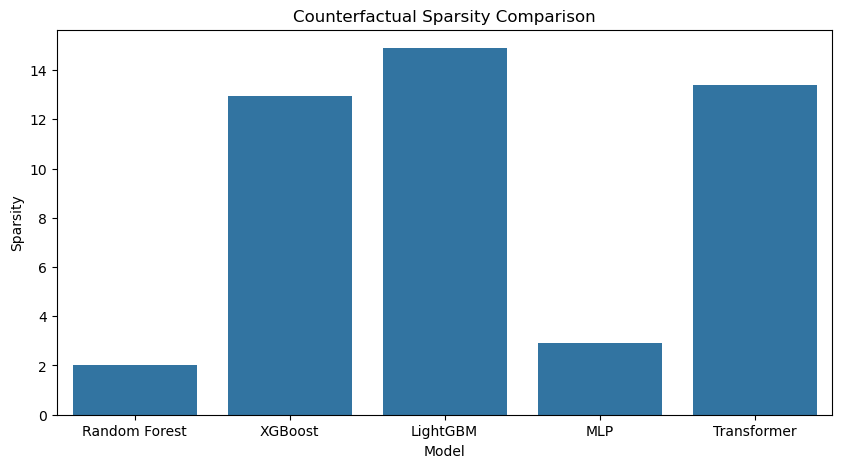

In [110]:
plt.figure(figsize=(10,5))


sns.barplot(

    data=xai_results_df,

    x="Model",

    y="Sparsity"

)


plt.title(
    "Counterfactual Sparsity Comparison"
)


plt.show()

C:\Users\farda\AppData\Local\Temp\ipykernel_13496\670987286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


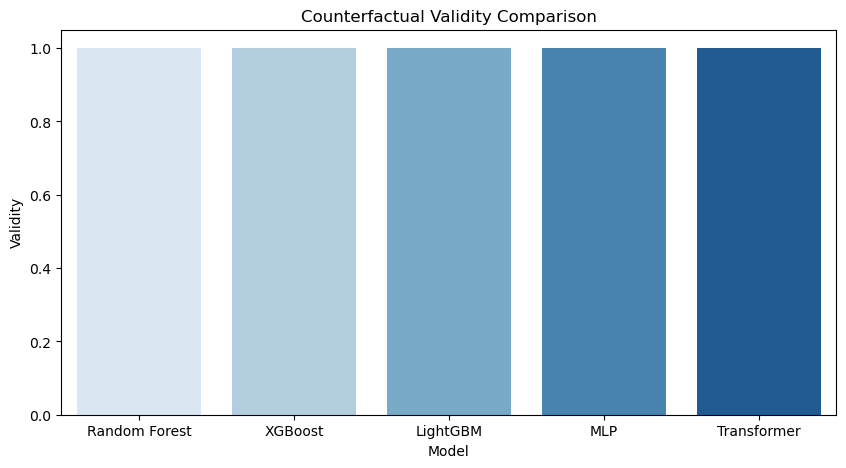

In [111]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=xai_results_df,
    x="Model",
    y="Validity",
    palette="Blues"
)

plt.title("Counterfactual Validity Comparison")
plt.ylim(0, 1.05)
plt.ylabel("Validity")

plt.show()

C:\Users\farda\AppData\Local\Temp\ipykernel_13496\3289452888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


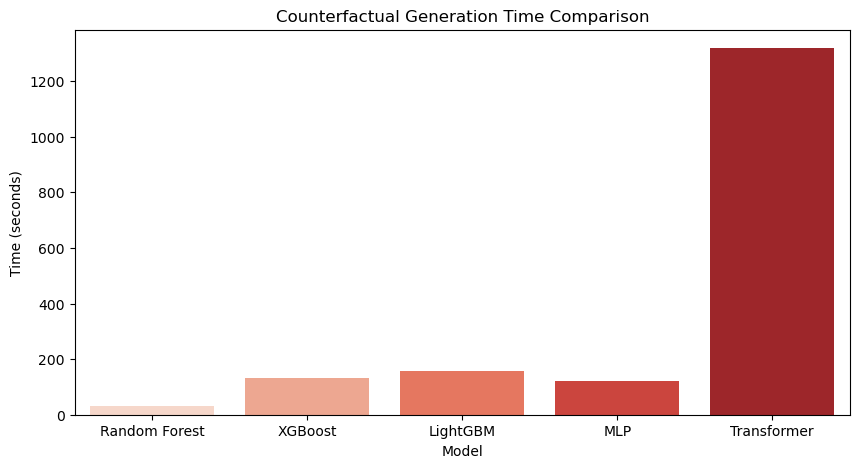

In [112]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=xai_results_df,
    x="Model",
    y="Generation_Time_sec",
    palette="Reds"
)

plt.title("Counterfactual Generation Time Comparison")
plt.ylabel("Time (seconds)")

plt.show()

C:\Users\farda\AppData\Local\Temp\ipykernel_13496\3813879817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


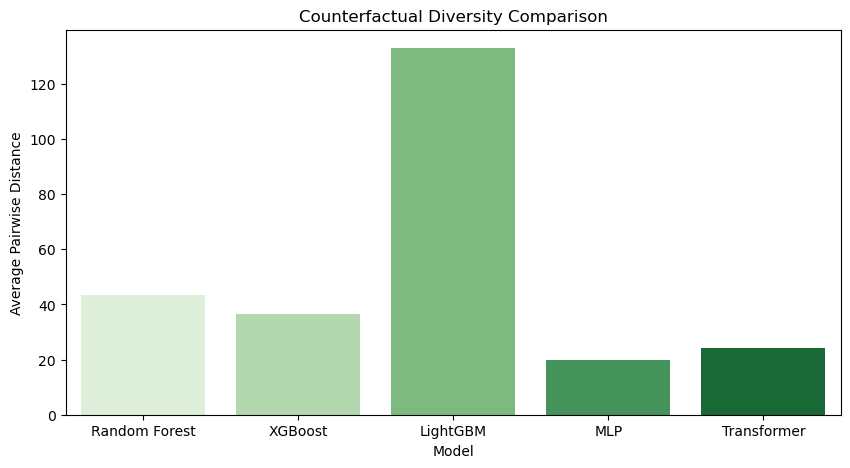

In [113]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=xai_results_df,
    x="Model",
    y="Diversity",
    palette="Greens"
)

plt.title("Counterfactual Diversity Comparison")
plt.ylabel("Average Pairwise Distance")

plt.show()

In [ ]:
xai_results_df.to_csv(
    "DiCE_Explainability_Comparison.csv",
    index=False
)

print("Saved")

Explainability results saved successfully.
